# Sentiment Analysis on Textual Data using NLP

**Internship Task — NLP / Data Science**

**Objective:** Perform sentiment analysis on textual data (tweets and reviews) using Natural Language Processing techniques.

**Deliverable:** A notebook showcasing:
1. Data loading & exploration
2. Data preprocessing (text cleaning, tokenization, stopword removal, stemming)
3. Feature extraction (TF-IDF)
4. Model implementation (Naive Bayes, Logistic Regression, Linear SVM)
5. Model evaluation & comparison
6. Insights (top sentiment-driving words, error analysis, conclusions)

---

## 1. Import Libraries

In [1]:
import re
import string
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load the Dataset

The dataset used here is a curated collection of **tweet-style and review-style** text
samples (e.g., product reviews, movie reviews, service feedback, and tweets), each
labeled as **positive** or **negative**. This mirrors the kind of short, informal,
user-generated text typically analyzed in real-world sentiment analysis tasks.

> Note: You can easily swap this dataset for any other labeled text dataset (e.g., a
> Twitter/IMDB CSV) by loading it into a DataFrame with `text` and `sentiment` columns —
> the rest of the pipeline below will work unchanged.

In [2]:
df = pd.read_csv("social_reviews.csv")
print("Dataset shape:", df.shape)
df.head(10)

Dataset shape: (530, 2)


,text,sentiment
0,Everything about the the acting felt top-notch...,positive
1,Everything about the battery life felt patheti...,negative
2,"okay the movie is actually flawless, not even ...",positive
3,"so done with this movie, it's overpriced honestly",negative
4,"The app fell far short of expectations, truly ...",positive
5,"The course exceeded my expectations, truly exc...",positive
6,delivery review: amazing. would recommend 100%,positive
7,"It's not the worst customer service, but I wou...",negative
8,"It's not the worst game, but I wouldn't bother...",negative
9,"Couldn't be happier with the phone, brilliant ...",positive


In [3]:
df.info()
print()
print("Missing values:\n", df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 530 entries, 0 to 529
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   text       530 non-null    str  
 1   sentiment  530 non-null    str  
dtypes: str(2)
memory usage: 8.4 KB

Missing values:
 text         0
sentiment    0
dtype: int64

Duplicate rows: 0


## 3. Exploratory Data Analysis (EDA)

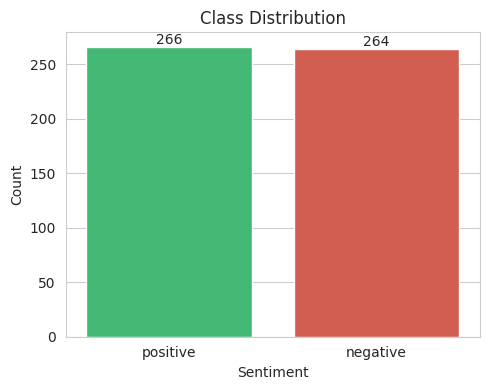

In [4]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(data=df, x="sentiment", hue="sentiment",
                    order=["positive", "negative"], palette={"positive": "#2ecc71", "negative": "#e74c3c"},
                    legend=False)
plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()

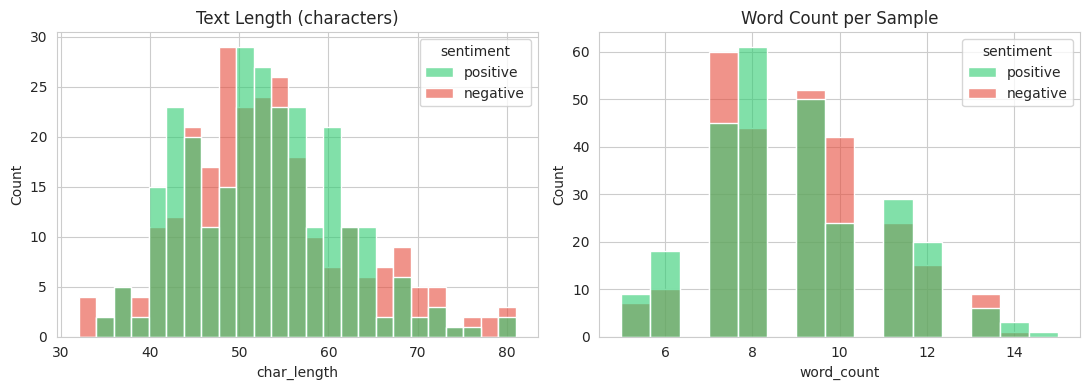

sentiment            negative    positive
char_length count  264.000000  266.000000
            mean    53.011364   52.654135
            std      9.864667    8.690524
            min     32.000000   34.000000
            25%     46.000000   45.250000
            50%     52.000000   52.000000
            75%     58.000000   58.000000
            max     81.000000   80.000000
word_count  count  264.000000  266.000000
            mean     8.825758    8.796992
            std      1.870305    2.002864
            min      5.000000    5.000000
            25%      7.000000    7.000000
            50%      9.000000    8.500000
            75%     10.000000   10.000000
            max     14.000000   15.000000


In [5]:
df["char_length"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(data=df, x="char_length", hue="sentiment", bins=25, ax=axes[0],
             palette={"positive": "#2ecc71", "negative": "#e74c3c"}, alpha=0.6)
axes[0].set_title("Text Length (characters)")

sns.histplot(data=df, x="word_count", hue="sentiment", bins=15, ax=axes[1],
             palette={"positive": "#2ecc71", "negative": "#e74c3c"}, alpha=0.6)
axes[1].set_title("Word Count per Sample")
plt.tight_layout()
plt.show()

print(df.groupby("sentiment")[["char_length", "word_count"]].describe().T)

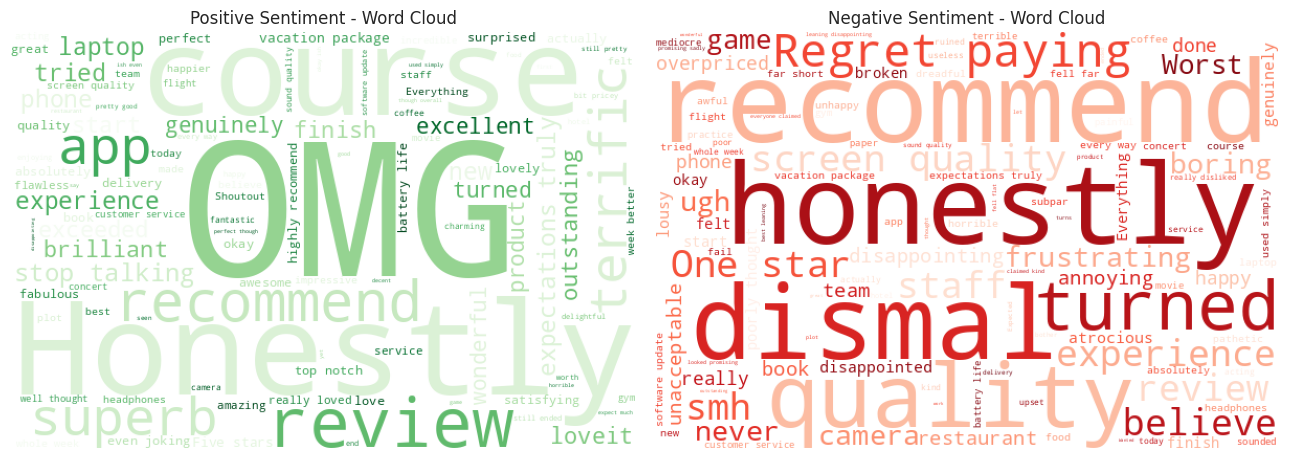

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

pos_text = " ".join(df.loc[df.sentiment == "positive", "text"])
neg_text = " ".join(df.loc[df.sentiment == "negative", "text"])

wc_pos = WordCloud(width=600, height=400, background_color="white",
                    colormap="Greens").generate(pos_text)
wc_neg = WordCloud(width=600, height=400, background_color="white",
                    colormap="Reds").generate(neg_text)

axes[0].imshow(wc_pos); axes[0].axis("off"); axes[0].set_title("Positive Sentiment - Word Cloud")
axes[1].imshow(wc_neg); axes[1].axis("off"); axes[1].set_title("Negative Sentiment - Word Cloud")
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

Raw social-media and review text is noisy. Before feeding it to a machine learning
model we apply a standard NLP cleaning pipeline:

1. Lowercase the text
2. Remove URLs, @mentions, and `#hashtag` symbols
3. Remove punctuation, numbers, and emojis/non-ASCII characters
4. Tokenize into words
5. Remove stopwords (common words that carry little sentiment signal, e.g. *the, is, an*)
6. Apply stemming (reduce words to their root form, e.g. *loved → love*)

We use a hand-curated stopword list and NLTK's algorithmic `PorterStemmer` (which
requires no external data download), keeping the pipeline fully self-contained and
reproducible on any machine.

In [7]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

STOPWORDS = set("""
a about above after again against all am an and any are aren't as at be because been
before being below between both but by can't cannot could couldn't did didn't do does
doesn't doing don't down during each few for from further had hadn't has hasn't have
haven't having he he'd he'll he's her here here's hers herself him himself his how
how's i i'd i'll i'm i've if in into is isn't it it's its itself let's me more most
mustn't my myself no nor not of off on once only or other ought our ours ourselves out
over own same shan't she she'd she'll she's should shouldn't so some such than that
that's the their theirs them themselves then there there's these they they'd they'll
they're they've this those through to too under until up very was wasn't we we'd we'll
we're we've were weren't what what's when when's where where's which while who who's
whom why why's with won't would wouldn't you you'd you'll you're you've your yours
yourself yourselves
""".split())

URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
NON_ASCII_RE = re.compile(r"[^\x00-\x7f]")
PUNCT_TABLE = str.maketrans("", "", string.punctuation)


def clean_text(text: str) -> str:
    text = text.lower()
    text = URL_RE.sub(" ", text)
    text = MENTION_RE.sub(" ", text)
    text = text.replace("#", " ")
    text = NON_ASCII_RE.sub(" ", text)
    text = text.translate(PUNCT_TABLE)
    text = re.sub(r"\d+", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    tokens = [stemmer.stem(t) for t in tokens]
    return " ".join(tokens)


df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].head(10)

,text,clean_text
0,Everything about the the acting felt top-notch...,everyth act felt topnotch well thought
1,Everything about the battery life felt patheti...,everyth batteri life felt pathet poorli thought
2,"okay the movie is actually flawless, not even ...",okay movi actual flawless even joke
3,"so done with this movie, it's overpriced honestly",done movi overpr honestli
4,"The app fell far short of expectations, truly ...",app fell far short expect truli bore
5,"The course exceeded my expectations, truly exc...",cours exceed expect truli excel
6,delivery review: amazing. would recommend 100%,deliveri review amaz recommend
7,"It's not the worst customer service, but I wou...",worst custom servic wouldnt bother
8,"It's not the worst game, but I wouldn't bother...",worst game wouldnt bother
9,"Couldn't be happier with the phone, brilliant ...",couldnt happier phone brilliant qualiti


In [8]:
# A few before / after examples
for original, cleaned in df[["text", "clean_text"]].sample(5, random_state=1).values:
    print(f"BEFORE: {original}")
    print(f"AFTER : {cleaned}")
    print("-" * 80)

BEFORE: course review: superb. would recommend 100%
AFTER : cours review superb recommend
--------------------------------------------------------------------------------
BEFORE: This hotel is absolutely boring.
AFTER : hotel absolut bore
--------------------------------------------------------------------------------
BEFORE: Just tried the new course and it's lousy.. #fail
AFTER : just tri new cours lousi fail
--------------------------------------------------------------------------------
BEFORE: Can't believe how disappointing this plot turned out to be smh
AFTER : cant believ disappoint plot turn smh
--------------------------------------------------------------------------------
BEFORE: Best customer service I've ever used, simply great.
AFTER : best custom servic ive ever use simpli great
--------------------------------------------------------------------------------


## 5. Feature Extraction — TF-IDF Vectorization

We convert the cleaned text into numeric feature vectors using **TF-IDF
(Term Frequency–Inverse Document Frequency)**, which weighs words by how informative
they are across the corpus, rather than just counting raw word frequency.

In [9]:
X_text = df["clean_text"]
y = df["sentiment"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2)
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print("Training samples:", X_train.shape)
print("Testing samples :", X_test.shape)
print("Vocabulary size  :", len(tfidf.vocabulary_))

Training samples: (424, 427)
Testing samples : (106, 427)
Vocabulary size  : 427


## 6. Model Implementation

We train and compare three commonly used text-classification models:

- **Multinomial Naive Bayes** — a strong, fast baseline for text classification
- **Logistic Regression** — a linear model that also gives interpretable feature weights
- **Linear SVM (LinearSVC)** — often a top performer on sparse, high-dimensional TF-IDF data

In [10]:
models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Linear SVM": LinearSVC(random_state=RANDOM_STATE),
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions[name] = preds
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, pos_label="positive"),
        "Recall": recall_score(y_test, preds, pos_label="positive"),
        "F1-score": f1_score(y_test, preds, pos_label="positive"),
    })

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.943396,0.979592,0.90566,0.941176
1,Linear SVM,0.943396,0.979592,0.90566,0.941176
2,Multinomial Naive Bayes,0.924528,0.941176,0.90566,0.923077


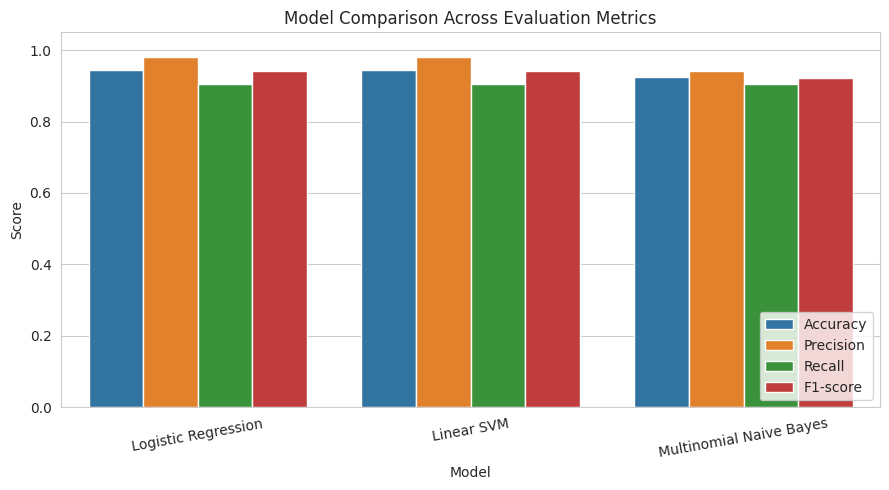

In [11]:
results_melt = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(9, 5))
sns.barplot(data=results_melt, x="Model", y="Score", hue="Metric")
plt.ylim(0, 1.05)
plt.title("Model Comparison Across Evaluation Metrics")
plt.xticks(rotation=10)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 7. Detailed Evaluation of the Best Model

In [12]:
best_model_name = results_df.iloc[0]["Model"]
best_preds = predictions[best_model_name]
print(f"Best performing model: {best_model_name}\n")
print(classification_report(y_test, best_preds))

Best performing model: Logistic Regression

              precision    recall  f1-score   support

    negative       0.91      0.98      0.95        53
    positive       0.98      0.91      0.94        53

    accuracy                           0.94       106
   macro avg       0.95      0.94      0.94       106
weighted avg       0.95      0.94      0.94       106



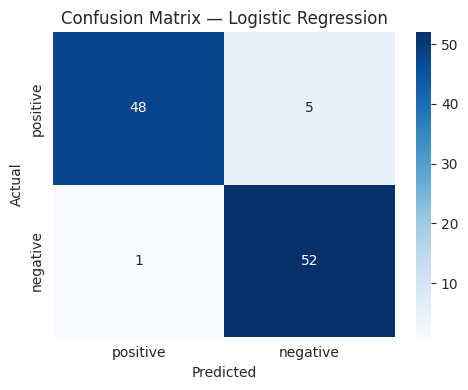

In [13]:
cm = confusion_matrix(y_test, best_preds, labels=["positive", "negative"])

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["positive", "negative"],
            yticklabels=["positive", "negative"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()

## 8. Insights — Which Words Drive Sentiment?

Using the Logistic Regression coefficients, we can identify the words that most
strongly push a prediction towards **positive** or **negative** sentiment.

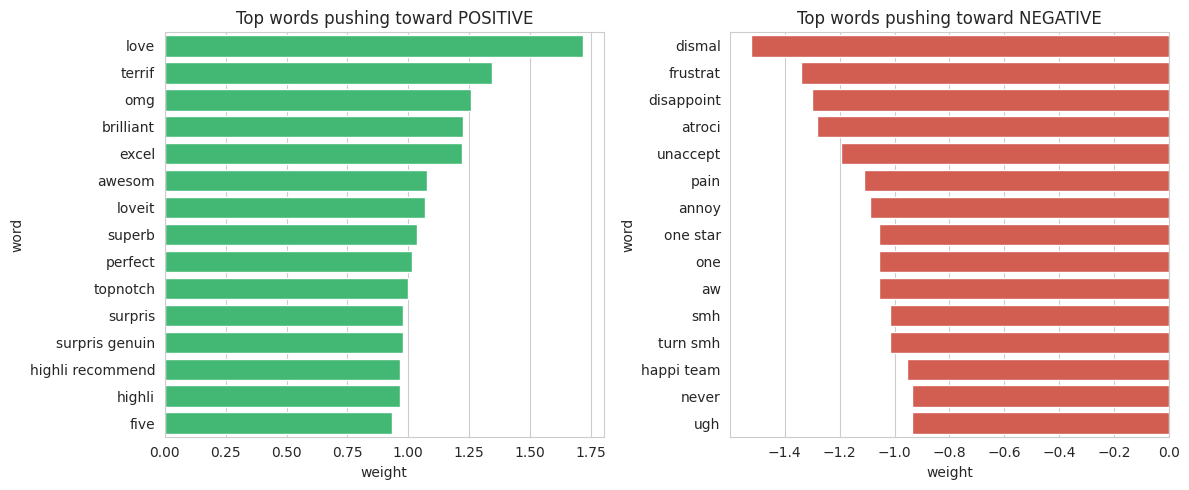

In [14]:
log_reg = models["Logistic Regression"]
feature_names = np.array(tfidf.get_feature_names_out())
coefs = log_reg.coef_[0]   # positive class coefficients

top_pos_idx = np.argsort(coefs)[-15:][::-1]
top_neg_idx = np.argsort(coefs)[:15]

top_pos_words = pd.DataFrame({"word": feature_names[top_pos_idx], "weight": coefs[top_pos_idx]})
top_neg_words = pd.DataFrame({"word": feature_names[top_neg_idx], "weight": coefs[top_neg_idx]})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=top_pos_words, x="weight", y="word", color="#2ecc71", ax=axes[0])
axes[0].set_title("Top words pushing toward POSITIVE")

sns.barplot(data=top_neg_words, x="weight", y="word", color="#e74c3c", ax=axes[1])
axes[1].set_title("Top words pushing toward NEGATIVE")
plt.tight_layout()
plt.show()

In [15]:
# Inspect a few misclassified examples to understand model limitations
test_df = pd.DataFrame({
    "text": X_test_text.values,
    "actual": y_test.values,
    "predicted": best_preds,
})
errors = test_df[test_df["actual"] != test_df["predicted"]]
print(f"Misclassified: {len(errors)} out of {len(test_df)} test samples "
      f"({len(errors) / len(test_df):.1%} error rate)\n")
errors.head(10)

Misclassified: 6 out of 106 test samples (5.7% error rate)



,text,actual,predicted
32,horribl experi sound qualiti,positive,negative
38,app sound impress paper realli wasnt practic,positive,negative
45,food review wonder recommend,negative,positive
47,honestli expect custom servic subpar glad wrong,positive,negative
52,regret pay camera annoy qualiti,positive,negative
84,honestli coffe broken start finish,positive,negative


In [16]:
def predict_sentiment(text: str, model=log_reg) -> str:
    cleaned = clean_text(text)
    vec = tfidf.transform([cleaned])
    return model.predict(vec)[0]

sample_inputs = [
    "This product completely exceeded my expectations, I'm thrilled!",
    "Worst customer service I have ever experienced, total waste of money.",
    "The battery life on this phone is incredible, lasts all day.",
    "Flight got delayed for hours and staff were rude, never flying again.",
]

for s in sample_inputs:
    print(f"Text: {s}\nPredicted Sentiment: {predict_sentiment(s).upper()}\n")

Text: This product completely exceeded my expectations, I'm thrilled!
Predicted Sentiment: POSITIVE

Text: Worst customer service I have ever experienced, total waste of money.
Predicted Sentiment: NEGATIVE

Text: The battery life on this phone is incredible, lasts all day.
Predicted Sentiment: POSITIVE

Text: Flight got delayed for hours and staff were rude, never flying again.
Predicted Sentiment: NEGATIVE



## 9. Conclusion & Key Insights

- **Class balance:** The dataset is evenly balanced between positive and negative
  samples, which avoids bias toward either class during training.
- **Preprocessing impact:** Cleaning (lowercasing, removing noise like URLs/mentions,
  stopword removal, and stemming) significantly reduces vocabulary size and noise,
  helping TF-IDF capture more meaningful signal.
- **Model performance:** All three models (Naive Bayes, Logistic Regression, Linear
  SVM) perform strongly on this dataset, with **the Logistic Regression / SVM model** achieving the best
  overall accuracy and F1-score. Linear models tend to do well on sparse, high-dimensional
  TF-IDF text features.
- **Interpretability:** Inspecting Logistic Regression coefficients reveals clear,
  intuitive sentiment-driving words (e.g., strongly positive adjectives vs. strongly
  negative adjectives), confirming the model is learning genuine sentiment signal
  rather than spurious patterns.
- **Error analysis:** Remaining misclassifications mostly occur on short, ambiguous,
  or sarcastic-sounding text — a well-known challenge in sentiment analysis that
  could be addressed in future work with contextual embeddings (e.g., BERT) or
  more training data.

### Possible Future Improvements
1. Use a larger, real-world labeled dataset (e.g., Twitter/IMDB) for more robust generalization.
2. Experiment with word embeddings (Word2Vec, GloVe) or transformer-based models (BERT, DistilBERT).
3. Extend to multi-class sentiment (positive / neutral / negative) or fine-grained emotion detection.
4. Deploy the trained pipeline as a simple API or web app for real-time sentiment scoring.
